# Model Comparison

This notebook compares Decision Tree, KNN, SVM and Random Forest using the same training, validation and untouched test sets. The final table uses macro precision, recall and F1-score for all models.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

sns.set_theme(style="whitegrid")
os.makedirs("../outputs", exist_ok=True)

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

## Load and Split the Dataset

The split below is exactly the same setup used in each model notebook.

In [2]:
df = pd.read_csv("../Dataset/Crop_recommendation_dataset.csv")
features = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]
X = df[features]
y = df["label"]

# First keep 20% aside for the final test set.
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 25% of the remaining 80% gives 20% of the full dataset for validation.
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (1320, 7)
Validation set: (440, 7)
Test set: (440, 7)


## Prepare Final Training Data

The individual notebooks already used validation data to select hyperparameters. For the final comparison, we combine training and validation so every final model trains on the same 80% of the dataset. KNN and SVM use a scaler fitted on this combined data.


In [3]:
X_train_final = pd.concat([X_train, X_val])
y_train_final = pd.concat([y_train, y_val])

final_scaler = StandardScaler()
X_train_final_scaled = final_scaler.fit_transform(X_train_final)
X_test_final_scaled = final_scaler.transform(X_test)

print("Final training set:", X_train_final.shape)
print("Final test set:", X_test.shape)


Final training set: (1760, 7)
Final test set: (440, 7)


## Train the Four Final Models

We use the settings selected from the validation work in the individual notebooks.

In [4]:
dt_model = DecisionTreeClassifier(criterion="entropy", max_depth=8, min_samples_split=2, min_samples_leaf=1, random_state=42)
dt_model.fit(X_train_final, y_train_final)

knn_model = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X_train_final_scaled, y_train_final)

svm_model = SVC(C=100, kernel="rbf")
svm_model.fit(X_train_final_scaled, y_train_final)

rf_model = RandomForestClassifier(n_estimators=200, max_depth=None, min_samples_leaf=1, random_state=42)
rf_model.fit(X_train_final, y_train_final)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## Final Test Results

Each model is evaluated once on the same test samples. This makes the comparison fair.

In [5]:
models = {
    "Decision Tree": (dt_model, X_test),
    "KNN": (knn_model, X_test_final_scaled),
    "SVM": (svm_model, X_test_final_scaled),
    "Random Forest": (rf_model, X_test)
}

rows = []
for name, (model, test_data) in models.items():
    pred = model.predict(test_data)
    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, average="macro"),
        "Recall": recall_score(y_test, pred, average="macro"),
        "F1-score": f1_score(y_test, pred, average="macro")
    })

results_df = pd.DataFrame(rows).sort_values("F1-score", ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
results_df.to_csv("../outputs/model_comparison_metrics.csv", index=False)


        Model  Accuracy  Precision  Recall  F1-score
Random Forest    0.9932     0.9935  0.9932    0.9932
          SVM    0.9886     0.9894  0.9886    0.9886
Decision Tree    0.9886     0.9894  0.9886    0.9885
          KNN    0.9773     0.9790  0.9773    0.9771


## Comparison Plot

The graph shows the four main metrics side by side. Higher values are better.

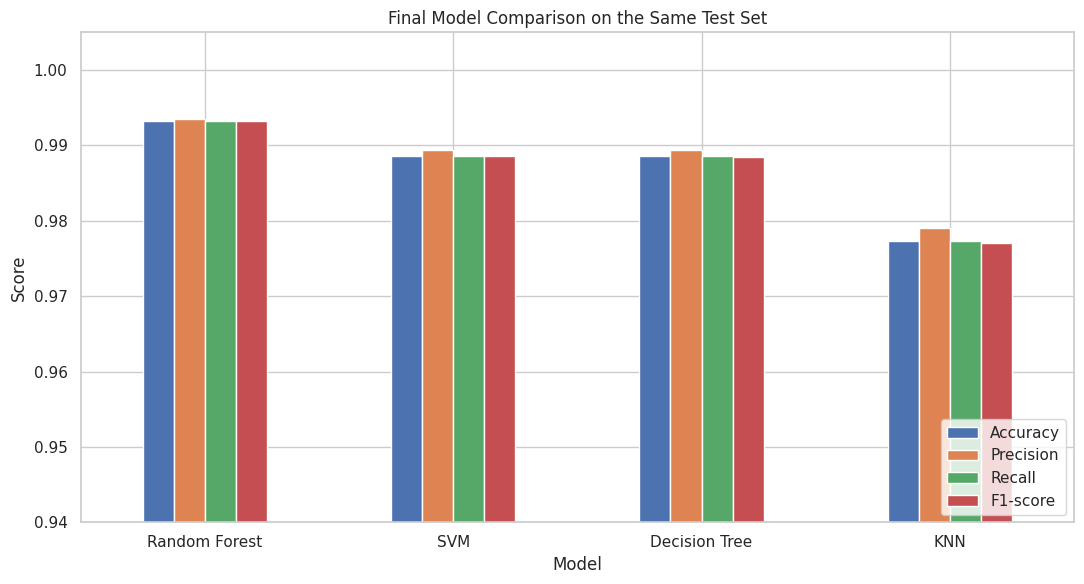

In [6]:
plot_df = results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-score"]]
ax = plot_df.plot(kind="bar", figsize=(11, 6))
plt.title("Final Model Comparison on the Same Test Set")
plt.ylabel("Score")
plt.ylim(0.94, 1.005)
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../outputs/model_comparison.png", dpi=220, bbox_inches="tight")
plt.show()

## Best Model and Deployment Choice

We identify the best-performing model using the real final test results. The application still uses Random Forest as the deployed model. If Random Forest is also the best model, then the evaluation and deployment choice agree.

In [7]:
best_model = results_df.iloc[0]["Model"]
best_f1 = results_df.iloc[0]["F1-score"]
rf_f1 = results_df.loc[results_df["Model"] == "Random Forest", "F1-score"].iloc[0]

print(f"Best-performing model: {best_model}")
print(f"Best macro F1-score: {best_f1:.4f}")
print(f"Random Forest macro F1-score: {rf_f1:.4f}")

if best_model == "Random Forest":
    print("Random Forest is both the best-performing model and the deployed model.")
else:
    print("Another model performed best, but Random Forest remains the deployed model because it still performs strongly and supports the prediction-explanation approach used in the application.")


Best-performing model: Random Forest
Best macro F1-score: 0.9932
Random Forest macro F1-score: 0.9932
Random Forest is both the best-performing model and the deployed model.


## Final Finding

The four models were compared under the same conditions. The final conclusion is based on the real test results rather than choosing a winner in advance. The saved Random Forest model is used by the application because it combines strong performance with useful feature importance.